In [1]:
from langgraph.graph import StateGraph, START,END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv
import os


In [2]:
load_dotenv()  # Load environment variables from .env file

True

In [3]:
class Employee(TypedDict):
    emp_name:str
    monthly_salary:int
    working_days:int
    complete_projects:int
    yearly_salary:int
    bonus:int
    project_status:str
    summary:str


In [4]:
def calcsal(state:Employee):
    yearly_salary=state['monthly_salary']*12
    return{
        'yearly_salary':yearly_salary   
    }

In [5]:
def  calbns(state:Employee):
    bonus=state['monthly_salary']*2
    return{
        'bonus':bonus }

In [6]:
def projeval(state:Employee):
    if state['complete_projects']>=5:
        status='excellent'
    else:
        status='average'
    return{
        'project_status':status
    }

In [7]:
def summary(state:Employee):
    summary=f"Employee {state['emp_name']} has a yearly salary of {state['yearly_salary']}, a bonus of {state['bonus']}, and their project status is {state['project_status']}."
    return{
        'summary':summary}

In [10]:
graph=StateGraph(Employee)
graph.add_node('calcsal',calcsal)
graph.add_node('calbns',calbns)
graph.add_node('projeval',projeval)
graph.add_node('summary',summary)

graph.add_edge(START,'calcsal')
graph.add_edge(START,'calbns')
graph.add_edge(START,'projeval')
graph.add_edge('calcsal','summary')
graph.add_edge('calbns','summary')
graph.add_edge('projeval','summary')
graph.add_edge('summary',END)
wf=graph.compile()


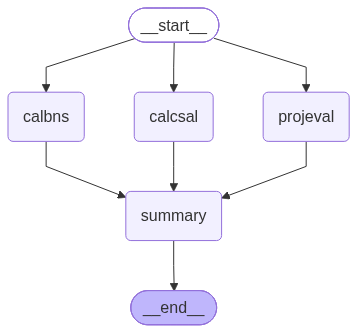

In [11]:
wf

In [12]:
ini={
    'emp_name':'John Doe',
    'monthly_salary':50000,
    'working_days':22,
    'complete_projects':7
}
res=wf.invoke(ini)

In [13]:
res

{'emp_name': 'John Doe',
 'monthly_salary': 50000,
 'working_days': 22,
 'complete_projects': 7,
 'yearly_salary': 600000,
 'bonus': 100000,
 'project_status': 'excellent',
 'summary': 'Employee John Doe has a yearly salary of 600000, a bonus of 100000, and their project status is excellent.'}